# ETS Model Benchmark — smooth 1.0.9

Rerun of the ETS comparison on the M1, M3 and Tourism competition series (5,315
in total) after the backcasting rewrite on the `backcast-warmstart` branch.

**Only the smooth rows were recomputed.** The ten `ADAM`/`ES` rows ran again on
the current build; the four competitor rows (`statsforecast`, `sktime`,
`skforecast`, `aeon`) are read from the saved arrays of the previous full run and
carried into the tables unchanged, since none of those packages changed. Every
table carries a `Source` column giving the run each row comes from, so no row
silently mixes the two.

**Packages:**
- **smooth** (ADAM, ES) — automatic selection via `Z` (AIC-based) — *rerun today*
- **statsforecast**, **sktime**, **skforecast**, **aeon** — AutoETS — *from the saved run*

**Metrics:** RMSSE, SAME, computational time, and the predictive distribution
(scaled pinball loss and calibration at the 99 levels `seq(0.01, 0.99, 0.01)`).

Launch the rerun with the BLAS threads pinned — `OMP_NUM_THREADS=1
OPENBLAS_NUM_THREADS=1 MKL_NUM_THREADS=1` — before the kernel starts. They have
to be set before NumPy is imported, so setting them inside the notebook is too
late, and without them each worker opens its own thread pool on top of the
process pool.

In [1]:
import numpy as np
import pandas as pd
import time
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing
import warnings
warnings.filterwarnings('ignore')

from fcompdata import M1, M3, Tourism

In [2]:
# Check which packages are available
from importlib.metadata import version as pkg_version
available_packages = {}

# Core environment (numpy/pandas affect every method's numeric backend)
import sys
print(f"python {sys.version.split()[0]}")
for _p in ('numpy', 'pandas'):
    print(f"{_p} v{pkg_version(_p)}")
print()

try:
    from smooth import ADAM, ES
    available_packages['smooth'] = True
    print(f"smooth v{pkg_version('smooth')}: Available")
except ImportError as e:
    available_packages['smooth'] = False
    print(f"smooth: Not available ({e})")

try:
    from statsforecast import models as sf_models
    available_packages['statsforecast'] = True
    print(f"statsforecast v{pkg_version('statsforecast')}: Available")
except ImportError as e:
    available_packages['statsforecast'] = False
    print(f"statsforecast: Not available ({e})")

try:
    from sktime.forecasting import ets as sktime_ets
    available_packages['sktime'] = True
    print(f"sktime v{pkg_version('sktime')}: Available")
except ImportError as e:
    available_packages['sktime'] = False
    print(f"sktime: Not available ({e})")

try:
    from skforecast.stats import Ets
    available_packages['skforecast'] = True
    print(f"skforecast v{pkg_version('skforecast')}: Available")
except ImportError as e:
    available_packages['skforecast'] = False
    print(f"skforecast: Not available ({e})")
try:
    from aeon.forecasting.stats import AutoETS as _AeonAutoETS
    available_packages['aeon'] = True
    print(f"aeon v{pkg_version('aeon')}: Available")
except ImportError as e:
    available_packages['aeon'] = False
    print(f"aeon: Not available ({e})")


python 3.14.4
numpy v2.3.5
pandas v2.3.3



smooth v1.0.9: Available


statsforecast v2.1.1: Available


sktime v1.0.1: Available


skforecast v0.23.0: Available
aeon v1.5.0: Available


## Error Metrics

In [3]:
def RMSSE(holdout, forecast, actuals):
    """
    Root Mean Squared Scaled Error.
    """
    holdout = np.asarray(holdout)
    forecast = np.asarray(forecast)
    actuals = np.asarray(actuals)
    
    mse = np.mean((holdout - forecast) ** 2)
    scale = np.mean(np.diff(actuals) ** 2)
    
    if scale == 0:
        return np.nan
    
    return np.sqrt(mse / scale)

def SAME(holdout, forecast, actuals):
    """
    Scaled Absolute Mean Error.
    """
    holdout = np.asarray(holdout)
    forecast = np.asarray(forecast)
    actuals = np.asarray(actuals)
    
    ame = np.abs(np.mean(holdout - forecast))
    scale = np.mean(np.abs(np.diff(actuals)))
    
    if scale == 0:
        return np.nan
    
    return ame / scale

## Load Datasets

In [4]:
# Combine datasets into a list
datasets = []
for idx in M1.keys():
    datasets.append(M1[idx])
for idx in M3.keys():
    datasets.append(M3[idx])
for idx in Tourism.keys():
    datasets.append(Tourism[idx])

print(f"Total series: {len(datasets)}")
print(f"M1: {len(M1)} series")
print(f"M3: {len(M3)} series")
print(f"Tourism: {len(Tourism)} series")

Total series: 5315
M1: 1001 series
M3: 3003 series
Tourism: 1311 series


## Define Methods

Methods are defined as tuples: `(method_name, package, config_dict)`

In [5]:
# All method configurations (automatic selection only)
all_methods_config = [
    # smooth package - ADAM and ES models with automatic selection (Z = AIC-based)
    ("ADAM ETS Back", "smooth", {"class": "ADAM", "model": "ZXZ", "initial": "backcasting"}),
    ("ADAM ETS Opt", "smooth", {"class": "ADAM", "model": "ZXZ", "initial": "optimal"}),
    ("ADAM ETS Two", "smooth", {"class": "ADAM", "model": "ZXZ", "initial": "two-stage"}),
    ("ES Back", "smooth", {"class": "ES", "model": "ZXZ", "initial": "backcasting"}),
    ("ES Opt", "smooth", {"class": "ES", "model": "ZXZ", "initial": "optimal"}),
    ("ES Two", "smooth", {"class": "ES", "model": "ZXZ", "initial": "two-stage"}),
    ("ES XXX", "smooth", {"class": "ES", "model": "XXX", "initial": "backcasting"}),
    ("ES ZZZ", "smooth", {"class": "ES", "model": "ZZZ", "initial": "backcasting"}),
    ("ES FFF", "smooth", {"class": "ES", "model": "FFF", "initial": "backcasting"}),
    ("ES SXS", "smooth", {"class": "ES", "model": "SXS", "initial": "backcasting"}),

    # statsforecast - AutoETS (AIC-based selection)
    ("statsforecast AutoETS", "statsforecast", {}),

    # sktime - AutoETS (AIC-based selection)
    ("sktime AutoETS", "sktime", {}),

    # skforecast - Ets with automatic selection (ZZZ)
    ("skforecast AutoETS", "skforecast", {}),

    # aeon - AutoETS (AIC-based selection)
    ("aeon AutoETS", "aeon", {}),
]

# The smooth rows are recomputed by this notebook; the rest are read from the
# saved arrays of the previous full run, so that the competitor numbers stay
# exactly as they were measured rather than being refitted here.
SMOOTH = [name for name, pkg, _ in all_methods_config if pkg == "smooth"]
COMPETITORS = [name for name, pkg, _ in all_methods_config if pkg != "smooth"]

smooth_methods_config = [m for m in all_methods_config if m[0] in SMOOTH]

# evaluate_parallel() writes each result into the row given by
# methods_names.index(name), so during the rerun these globals must describe the
# smooth-only grid. They are widened to all fourteen rows once the two runs are
# merged, below.
methods_config = smooth_methods_config
methods_names = [m[0] for m in methods_config]
methods_number = len(methods_names)
dataset_length = len(datasets)

print(f"rerun here:  {len(SMOOTH)} smooth rows")
for name in SMOOTH:
    print(f"    {name}")
print(f"read back:   {len(COMPETITORS)} competitor rows")
for name in COMPETITORS:
    print(f"    {name}")
print(f"\nDatasets: {dataset_length}")

rerun here:  10 smooth rows
    ADAM ETS Back
    ADAM ETS Opt
    ADAM ETS Two
    ES Back
    ES Opt
    ES Two
    ES XXX
    ES ZZZ
    ES FFF
    ES SXS
read back:   4 competitor rows
    statsforecast AutoETS
    sktime AutoETS
    skforecast AutoETS
    aeon AutoETS

Datasets: 5315


## Evaluation Functions

Each package has a different API, so we need separate evaluation functions.

In [6]:
def _evaluate_task(args):
    """
    Worker function for parallel evaluation.
    Handles different package APIs (automatic selection models only).
    """
    import numpy as np
    import time
    import warnings
    warnings.filterwarnings('ignore')
    
    series_idx, series, method_name, package, config = args
    
    try:
        start_time = time.time()
        forecast_values = None
        
        # ===== SMOOTH PACKAGE =====
        if package == "smooth":
            from smooth import ADAM, ES
            
            model_class = config.get("class", "ES")
            model_str = config.get("model", "ZXZ")
            initial = config.get("initial", "backcasting")
            
            if series.period > 1:
                lags = [1, series.period]
            else:
                lags = [1]
                if len(model_str) == 3 and model_str[2] != 'N':
                    model_str = model_str[:2] + 'N'
            
            ModelClass = ADAM if model_class == "ADAM" else ES
            model = ModelClass(model=model_str, lags=lags, initial=initial)
            model.fit(series.x)
            forecasts = model.predict(h=series.h)
            forecast_values = forecasts['mean'].values
        
        # ===== STATSFORECAST =====
        elif package == "statsforecast":
            from statsforecast import models as sf_models
            
            season_length = series.period if series.period > 1 else 1
            model = sf_models.AutoETS(season_length=season_length)
            model.fit(series.x)
            forecasts = model.predict(h=series.h)
            forecast_values = forecasts['mean'] if isinstance(forecasts, dict) else forecasts
        
        # ===== SKTIME =====
        elif package == "sktime":
            import pandas as pd
            from sktime.forecasting import ets as sktime_ets

            y = pd.Series(series.x)
            fh = np.arange(1, series.h + 1)
            sp = series.period if series.period > 1 else 1
            model = sktime_ets.AutoETS(sp=sp, auto=True)
            model.fit(y)
            forecast_values = model.predict(fh).values

        # ===== SKFORECAST =====
        elif package == "skforecast":
            from skforecast.stats import Ets

            season_length = series.period if series.period > 1 else 1
            model = Ets(model="ZZZ", m=season_length)
            model.fit(series.x)
            forecast_values = model.predict(steps=series.h)

        # ===== AEON =====
        elif package == "aeon":
            from aeon.forecasting.stats import AutoETS

            season_length = series.period if series.period > 1 else 1
            model = AutoETS(seasonal_period=season_length)
            x = np.asarray(series.x, dtype=float)
            model.fit(x)
            forecast_values = model.iterative_forecast(x, prediction_horizon=series.h)

        else:
            raise ValueError(f"Unknown package: {package}")
        
        time_elapsed = time.time() - start_time
        
        forecast_values = np.asarray(forecast_values).flatten()[:series.h]
        
        # Calculate metrics
        mse = np.mean((series.xx - forecast_values) ** 2)
        scale = np.mean(np.diff(series.x) ** 2)
        rmsse = np.sqrt(mse / scale) if scale != 0 else np.nan
        
        ame = np.abs(np.mean(series.xx - forecast_values))
        scale_same = np.mean(np.abs(np.diff(series.x)))
        same = ame / scale_same if scale_same != 0 else np.nan
        
        return (series_idx, method_name, rmsse, same, time_elapsed)
    
    except Exception as e:
        return (series_idx, method_name, np.nan, np.nan, np.nan)


def evaluate_parallel(datasets, methods_config, n_workers=None):
    """
    Evaluate all methods on all datasets in parallel.
    """
    if n_workers is None:
        n_workers = multiprocessing.cpu_count()
    
    methods_names = [m[0] for m in methods_config]
    n_methods = len(methods_names)
    n_datasets = len(datasets)
    
    results = np.full((n_methods, n_datasets, 3), np.nan)
    
    tasks = []
    for method_name, package, config in methods_config:
        for i, series in enumerate(datasets):
            tasks.append((i, series, method_name, package, config))
    
    print(f"Starting parallel evaluation with {n_workers} workers...")
    print(f"Total tasks: {len(tasks)} ({n_methods} methods × {n_datasets} series)")
    
    start_time = time.time()
    completed = 0
    
    _ctx = multiprocessing.get_context("fork")
    with ProcessPoolExecutor(max_workers=n_workers, mp_context=_ctx) as executor:
        futures = {executor.submit(_evaluate_task, task): task for task in tasks}
        
        for future in as_completed(futures):
            result = future.result()
            series_idx, method_name, rmsse, same, elapsed = result
            
            method_idx = methods_names.index(method_name)
            results[method_idx, series_idx, 0] = rmsse
            results[method_idx, series_idx, 1] = same
            results[method_idx, series_idx, 2] = elapsed
            
            completed += 1
            if completed % 1000 == 0:
                elapsed_total = time.time() - start_time
                rate = completed / elapsed_total
                remaining = (len(tasks) - completed) / rate
                print(f"  Progress: {completed}/{len(tasks)} ({100*completed/len(tasks):.1f}%) - "
                      f"ETA: {remaining/60:.1f} min")
    
    total_time = time.time() - start_time
    print(f"\nCompleted in {total_time/60:.1f} minutes ({total_time:.1f}s)")
    print(f"Average time per task: {total_time/len(tasks)*1000:.1f}ms")
    
    return results

## Run Evaluation

In [7]:
print(f"Available CPU cores: {multiprocessing.cpu_count()}")

# Recompute the ten smooth rows (~20 min at 20 workers) with BENCH_RERUN=1;
# otherwise load the newest saved smooth-only array. The competitor rows always
# come from the saved full-roster array of 2026-07-20.
import os, glob, datetime
RERUN = os.environ.get("BENCH_RERUN", "0") == "1"
_ncap = int(os.environ.get("BENCH_WORKERS", min(20, multiprocessing.cpu_count())))
date_str = datetime.datetime.now().strftime("%Y-%m-%d")
SAVED_POINT = "2026-07-20-benchmark-ets-all.npy"

if RERUN:
    smooth_results = evaluate_parallel(datasets, smooth_methods_config, n_workers=_ncap)
    np.save(f"{date_str}-benchmark-ets-smooth.npy", smooth_results)
    smooth_file = f"{date_str}-benchmark-ets-smooth.npy"
else:
    smooth_file = sorted(glob.glob("*-benchmark-ets-smooth.npy"), key=os.path.basename)[-1]
    smooth_results = np.load(smooth_file)

saved_results = np.load(SAVED_POINT)
saved_names = [m[0] for m in all_methods_config]
assert smooth_results.shape[0] == len(SMOOTH)
assert saved_results.shape[0] == len(saved_names)

# Merge: smooth rows from today's run, competitor rows from the saved one.
methods_names = [m[0] for m in all_methods_config]
methods_number = len(methods_names)
test_results = np.full((methods_number, len(datasets), 3), np.nan)
SOURCE = {}
for j, name in enumerate(methods_names):
    if name in SMOOTH:
        test_results[j] = smooth_results[SMOOTH.index(name)]
        SOURCE[name] = smooth_file[:10]
    else:
        test_results[j] = saved_results[saved_names.index(name)]
        SOURCE[name] = SAVED_POINT[:10]

# Guard against scoring a stale rerun: arrays written before the last edit to the
# smooth sources describe a different package than the one imported above.
_src_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "src", "smooth"))
_newest_source = max(os.path.getmtime(os.path.join(folder, f))
                     for folder, _, files in os.walk(_src_dir)
                     for f in files if f.endswith(".py"))
_stale = os.path.getmtime(smooth_file) < _newest_source
print(f"\nsmooth rows      {smooth_file}  {smooth_results.shape}")
print(f"competitor rows  {SAVED_POINT}  {saved_results.shape}")
print("smooth arrays postdate the smooth sources:", not _stale)
assert not _stale, "rerun the smooth rows: BENCH_RERUN=1"

print("\nPer-method summary:")
for j, method in enumerate(methods_names):
    print(f"  {method:24s} [{SOURCE[method]}]  RMSSE={np.nanmean(test_results[j, :, 0]):.4f}, "
          f"SAME={np.nanmean(test_results[j, :, 1]):.4f}, "
          f"Time={np.nanmean(test_results[j, :, 2]):.3f}s, "
          f"Failed={int(np.sum(np.isnan(test_results[j, :, 0])))}")

Available CPU cores: 32
Starting parallel evaluation with 16 workers...
Total tasks: 53150 (10 methods × 5315 series)


  Progress: 1000/53150 (1.9%) - ETA: 4.0 min


  Progress: 2000/53150 (3.8%) - ETA: 2.8 min


  Progress: 3000/53150 (5.6%) - ETA: 2.7 min


  Progress: 4000/53150 (7.5%) - ETA: 2.8 min


...

  Progress: 50000/53150 (94.1%) - ETA: 0.7 min


  Progress: 51000/53150 (96.0%) - ETA: 0.5 min


  Progress: 52000/53150 (97.8%) - ETA: 0.3 min


  Progress: 53000/53150 (99.7%) - ETA: 0.0 min



Completed in 12.3 minutes (735.2s)
Average time per task: 13.8ms

smooth rows      2026-09-24-benchmark-ets-smooth.npy  (10, 5315, 3)
competitor rows  2026-07-20-benchmark-ets-all.npy  (14, 5315, 3)
smooth arrays postdate the smooth sources: True

Per-method summary:
  ADAM ETS Back            [2026-09-24]  RMSSE=1.9472, SAME=1.9720, Time=0.060s, Failed=0
  ADAM ETS Opt             [2026-09-24]  RMSSE=1.9489, SAME=1.9691, Time=0.272s, Failed=0
  ADAM ETS Two             [2026-09-24]  RMSSE=1.9579, SAME=1.9877, Time=0.331s, Failed=0
  ES Back                  [2026-09-24]  RMSSE=1.9441, SAME=1.9658, Time=0.064s, Failed=0
  ES Opt                   [2026-09-24]  RMSSE=1.9477, SAME=1.9676, Time=0.287s, Failed=0
  ES Two                   [2026-09-24]  RMSSE=1.9562, SAME=1.9858, Time=0.353s, Failed=0
  ES XXX                   [2026-09-24]  RMSSE=1.9767, SAME=2.0128, Time=0.037s, Failed=0
  ES ZZZ                   [2026-09-24]  RMSSE=2.0500, SAME=2.1046, Time=0.106s, Failed=0
  ES FFF   

## Results Summary

In [8]:
def summary(metric, label, last_column):
    frame = pd.DataFrame({
        "Method": methods_names,
        "Source": [SOURCE[n] for n in methods_names],
        "Min": [np.nanmin(test_results[j, :, metric]) for j in range(methods_number)],
        "Q1": [np.nanquantile(test_results[j, :, metric], 0.25) for j in range(methods_number)],
        "Med": [np.nanmedian(test_results[j, :, metric]) for j in range(methods_number)],
        "Q3": [np.nanquantile(test_results[j, :, metric], 0.75) for j in range(methods_number)],
        "Max": [np.nanmax(test_results[j, :, metric]) for j in range(methods_number)],
        "Mean": [np.nanmean(test_results[j, :, metric]) for j in range(methods_number)],
        "Failed": [int(np.sum(np.isnan(test_results[j, :, metric]))) for j in range(methods_number)],
    })
    name, values = last_column
    frame.insert(len(frame.columns) - 1, name, values)
    print("\n" + "=" * 110 + f"\nEVALUATION RESULTS for {label} (All Series)\n" + "=" * 110)
    print(frame.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    return frame


mean_time = [np.nanmean(test_results[j, :, 2]) for j in range(methods_number)]
summary_rmsse = summary(0, "RMSSE", ("Mean Time (s)", mean_time))


EVALUATION RESULTS for RMSSE (All Series)
               Method     Source    Min     Q1    Med     Q3            Max        Mean  Mean Time (s)  Failed
        ADAM ETS Back 2026-09-24 0.0246 0.6700 1.1868 2.3357        51.6160      1.9472         0.0596       0
         ADAM ETS Opt 2026-09-24 0.0221 0.6681 1.1809 2.3386        51.6160      1.9489         0.2724       0
         ADAM ETS Two 2026-09-24 0.0246 0.6690 1.1933 2.3604        51.6160      1.9579         0.3315       0
              ES Back 2026-09-24 0.0245 0.6739 1.1893 2.3137        51.6160      1.9441         0.0642       0
               ES Opt 2026-09-24 0.0221 0.6707 1.1902 2.3597        51.6160      1.9477         0.2865       0
               ES Two 2026-09-24 0.0245 0.6760 1.1918 2.3443        51.6160      1.9562         0.3527       0
               ES XXX 2026-09-24 0.0244 0.6848 1.1807 2.3313        51.6160      1.9767         0.0372       0
               ES ZZZ 2026-09-24 0.0114 0.6737 1.1958 2.3341       11

In [9]:
summary_same = summary(1, "SAME", ("Mean Time (s)", mean_time))


EVALUATION RESULTS for SAME (All Series)
               Method     Source    Min     Q1    Med     Q3            Max       Mean  Mean Time (s)  Failed
        ADAM ETS Back 2026-09-24 0.0003 0.3784 1.0141 2.4253        56.2820     1.9720         0.0596       0
         ADAM ETS Opt 2026-09-24 0.0001 0.3802 1.0123 2.4606        55.1018     1.9691         0.2724       0
         ADAM ETS Two 2026-09-24 0.0001 0.3890 1.0357 2.4697        55.1019     1.9877         0.3315       0
              ES Back 2026-09-24 0.0000 0.3853 1.0310 2.4140        56.5176     1.9658         0.0642       0
               ES Opt 2026-09-24 0.0001 0.3752 1.0103 2.4482        54.6860     1.9676         0.2865       0
               ES Two 2026-09-24 0.0005 0.3931 1.0398 2.4750        54.6856     1.9858         0.3527       0
               ES XXX 2026-09-24 0.0004 0.3852 1.0288 2.4208        54.4284     2.0128         0.0372       0
               ES ZZZ 2026-09-24 0.0000 0.3972 1.0418 2.4617       145.7005   

In [10]:
total_min = [np.nansum(test_results[j, :, 2]) / 60 for j in range(methods_number)]
summary_time = summary(2, "computational time in seconds", ("Total (min)", total_min))


EVALUATION RESULTS for computational time in seconds (All Series)
               Method     Source    Min     Q1    Med     Q3    Max   Mean  Total (min)  Failed
        ADAM ETS Back 2026-09-24 0.0054 0.0209 0.0446 0.0708 0.4076 0.0596       5.2800       0
         ADAM ETS Opt 2026-09-24 0.0251 0.0991 0.1520 0.3880 1.4448 0.2724      24.1335       0
         ADAM ETS Two 2026-09-24 0.0267 0.1291 0.1993 0.4922 1.8667 0.3315      29.3637       0
              ES Back 2026-09-24 0.0053 0.0222 0.0487 0.0756 0.4523 0.0642       5.6866       0
               ES Opt 2026-09-24 0.0271 0.1111 0.1601 0.4151 1.4900 0.2865      25.3802       0
               ES Two 2026-09-24 0.0276 0.1363 0.2131 0.5310 1.8206 0.3527      31.2436       0
               ES XXX 2026-09-24 0.0047 0.0168 0.0316 0.0480 0.1803 0.0372       3.2946       0
               ES ZZZ 2026-09-24 0.0056 0.0230 0.0673 0.1235 0.9067 0.1055       9.3473       0
               ES FFF 2026-09-24 0.0172 0.1070 0.5138 0.7861 1.9029 0

## Series failed diagnostics

In [11]:
# Build series ID list matching the order in `datasets`
series_ids = list(M1.keys()) + list(M3.keys()) + list(Tourism.keys())
dataset_sizes = {"M1": len(M1), "M3": len(M3), "Tourism": len(Tourism)}
dataset_boundaries = {}
offset = 0
for name, size in dataset_sizes.items():
    dataset_boundaries[name] = (offset, offset + size)
    offset += size

print("=" * 70)
print("FAILED SERIES DIAGNOSTICS")
print("=" * 70)

any_failures = False
for j, method in enumerate(methods_names):
    failed_mask = np.isnan(test_results[j, :, 0])
    n_failed = failed_mask.sum()
    if n_failed == 0:
        continue
    any_failures = True
    failed_indices = np.where(failed_mask)[0]

    print(f"\n{method} ({n_failed} failures):")
    for ds_name, (lo, hi) in dataset_boundaries.items():
        ds_failed = [series_ids[i] for i in failed_indices if lo <= i < hi]
        if ds_failed:
            print(f"  {ds_name}: {', '.join(str(s) for s in ds_failed)}")

if not any_failures:
    print("\nNo failures detected.")

FAILED SERIES DIAGNOSTICS

No failures detected.


## Predictive Distribution Assessment (Pinball + Calibration)

Quantile forecasts at levels `seq(0.01, 0.99, 0.01)` (99 levels) for every method.
For each method we report:

- **Scaled pinball loss** per level (pinball averaged over the holdout horizon,
  divided by the in-sample scale `mean(|diff(train)|)` so it is comparable across
  series, like SAME), and its mean over all levels (≈ a scaled CRPS).
- **Calibration**: empirical coverage `P(y ≤ q_τ)` per level — the reliability curve
  vs the nominal level — and the **mean calibration error** `mean_τ |coverage_τ − τ|`.

Quantiles come from each package's native predictive distribution: smooth
`predict(interval="prediction", side="both")`, statsforecast `lo/hi` levels,
sktime `predict_quantiles`, skforecast `predict_interval`. **aeon has no quantile
API**, so its distributional metrics are `NaN`. Every quantile row is sorted
(monotone rearrangement) before scoring.

In [12]:
# Distributional results: the smooth rows from today's run, the competitor rows
# from the saved full-roster array. Shape per row: (n_series, 99, 2), with
# [..., 0] = scaled pinball and [..., 1] = coverage.
import glob, subprocess, sys
quantile_levels = np.round(np.arange(0.01, 1.0, 0.01), 2)   # 99 levels
dist_methods = [m[0] for m in all_methods_config]           # all 14, config order
SAVED_DIST = "2026-07-23-benchmark-dist.npy"

if os.environ.get("BENCH_RERUN_DIST", "0") == "1":
    subprocess.run([sys.executable, "run_dist_benchmark.py"], check=True,
                   env=dict(os.environ, BENCH_ONLY="adam ets,es ", BENCH_TAG="smooth",
                            BENCH_WORKERS=str(_ncap),
                            OMP_NUM_THREADS="1", OPENBLAS_NUM_THREADS="1",
                            MKL_NUM_THREADS="1"))

_smooth_dist_file = sorted(glob.glob("*-benchmark-dist-smooth.npy"), key=os.path.basename)[-1]
_smooth_dist = np.load(_smooth_dist_file)
with open(_smooth_dist_file.replace(".npy", "-methods.txt")) as f:
    _smooth_dist_names = [line.strip() for line in f if line.strip()]
_saved_dist = np.load(SAVED_DIST, mmap_mode="r")

dist_results = np.full((len(dist_methods), test_results.shape[1], 99, 2), np.nan)
DIST_SOURCE = {}
for j, name in enumerate(dist_methods):
    if name in _smooth_dist_names:
        dist_results[j] = _smooth_dist[_smooth_dist_names.index(name)]
        DIST_SOURCE[name] = _smooth_dist_file[:10]
    else:
        dist_results[j] = _saved_dist[dist_methods.index(name)]
        DIST_SOURCE[name] = SAVED_DIST[:10]

print(f"smooth rows      {_smooth_dist_file}  {_smooth_dist.shape}")
print(f"competitor rows  {SAVED_DIST}  {_saved_dist.shape}")
assert dist_results.shape[0] == len(dist_methods) and dist_results.shape[2] == 99

smooth rows      2026-09-24-benchmark-dist-smooth.npy  (10, 5315, 99, 2)
competitor rows  2026-07-23-benchmark-dist.npy  (14, 5315, 99, 2)


In [13]:
# Pinball + calibration summary (one row per method).
# Mean pinball is dominated by a few series where sktime/skforecast forecasts
# explode, so the robust Median (over series) pinball is reported alongside.
_pin = dist_results[:, :, :, 0]      # scaled pinball  (methods, series, 99)
_cov = dist_results[:, :, :, 1]      # coverage        (methods, series, 99)
_pin_series = np.nanmean(_pin, axis=2)   # (methods, series) mean over levels

rows = []
for j, name in enumerate(dist_methods):
    cov_curve = np.nanmean(_cov[j], axis=0)                 # (99,)
    if np.all(np.isnan(cov_curve)):
        rows.append({"Method": name, "Source": DIST_SOURCE[name], "Mean Pinball": np.nan,
                     "Median Pinball": np.nan, "MCE": np.nan, "Cov@0.1": np.nan,
                     "Cov@0.5": np.nan, "Cov@0.9": np.nan, "n (series)": 0})
        continue
    rows.append({"Method": name,
                 "Source": DIST_SOURCE[name],
                 "Mean Pinball": np.nanmean(_pin[j]),
                 "Median Pinball": np.nanmedian(_pin_series[j]),
                 "MCE": np.nanmean(np.abs(cov_curve - quantile_levels)),
                 "Cov@0.1": cov_curve[9], "Cov@0.5": cov_curve[49], "Cov@0.9": cov_curve[89],
                 "n (series)": int(np.sum(~np.isnan(_pin_series[j])))})

summary_dist = pd.DataFrame(rows).sort_values("Median Pinball")
print("\n" + "=" * 110)
print("PREDICTIVE DISTRIBUTION: scaled pinball (lower=better) + calibration MCE (lower=better)")
print("Median pinball is robust to the sktime/skforecast forecast blow-ups that inflate the mean.")
print("=" * 110)
print(summary_dist.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


PREDICTIVE DISTRIBUTION: scaled pinball (lower=better) + calibration MCE (lower=better)
Median pinball is robust to the sktime/skforecast forecast blow-ups that inflate the mean.
               Method     Source          Mean Pinball  Median Pinball    MCE  Cov@0.1  Cov@0.5  Cov@0.9  n (series)
               ES XXX 2026-09-24                0.8832          0.4894 0.0477   0.1302   0.4511   0.8161        5315
        ADAM ETS Back 2026-09-24                0.8592          0.5036 0.0528   0.1075   0.4283   0.8412        5315
         ADAM ETS Two 2026-09-24                0.8609          0.5039 0.0518   0.1074   0.4319   0.8376        5315
         ADAM ETS Opt 2026-09-24                0.8568          0.5041 0.0499   0.1060   0.4353   0.8393        5315
               ES Opt 2026-09-24                0.8482          0.5086 0.0412   0.0945   0.4500   0.8465        5315
       sktime AutoETS 2026-07-23            22334.9594          0.5089 0.0490   0.1165   0.4380   0.8316        5315
 

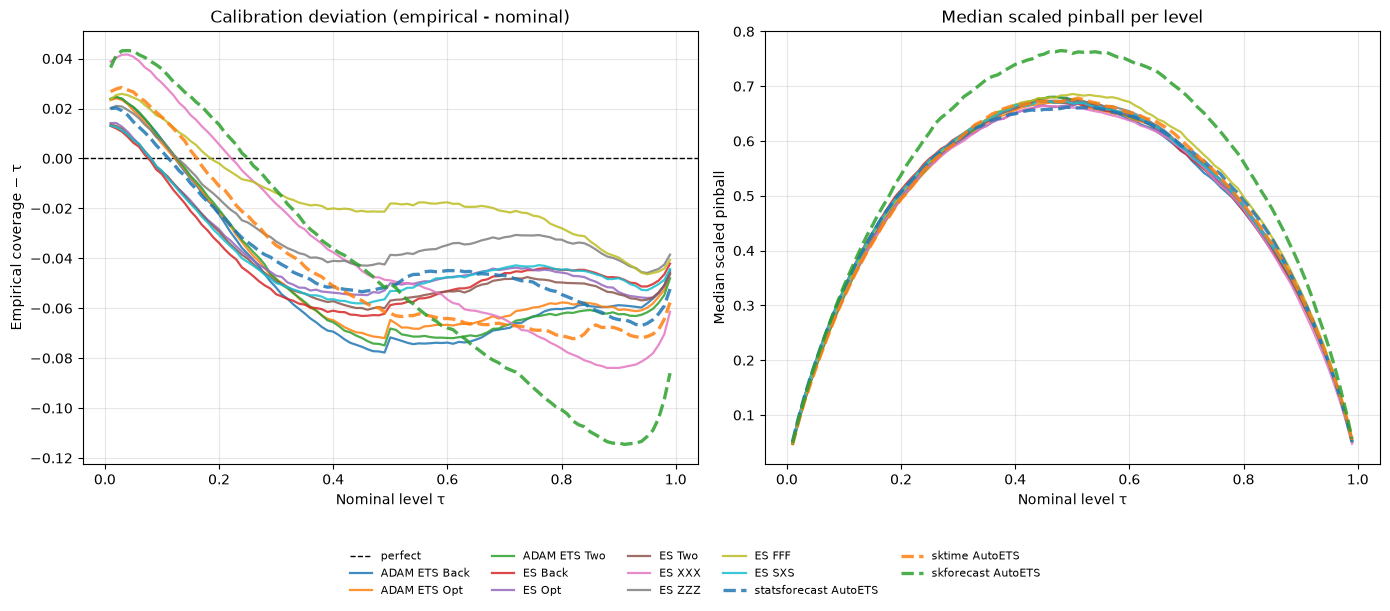

In [14]:
# Calibration deviation (empirical coverage - nominal) + per-level pinball.
# Deviation on the y-axis: 0 = perfectly calibrated, >0 over-covered, <0 under.
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].axhline(0.0, color="k", ls="--", lw=1, label="perfect")
for j, name in enumerate(dist_methods):
    cov = np.nanmean(_cov[j], axis=0)
    if np.all(np.isnan(cov)):
        continue
    is_smooth = not name.endswith("AutoETS")
    ax[0].plot(quantile_levels, cov - quantile_levels, lw=1.6 if is_smooth else 2.4,
               ls="-" if is_smooth else "--", alpha=0.85, label=name)
    ax[1].plot(quantile_levels, np.nanmedian(_pin[j], axis=0), lw=1.6 if is_smooth else 2.4,
               ls="-" if is_smooth else "--", alpha=0.85, label=name)
ax[0].set(title="Calibration deviation (empirical - nominal)", xlabel="Nominal level \u03c4",
          ylabel="Empirical coverage \u2212 \u03c4")
ax[1].set(title="Median scaled pinball per level", xlabel="Nominal level \u03c4",
          ylabel="Median scaled pinball")
ax[0].grid(alpha=0.3); ax[1].grid(alpha=0.3)
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, fontsize=8, frameon=False,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.12, 1, 1]); plt.show()


## Change against the previous smooth run

The saved arrays still hold the ten smooth rows as they were before the
backcasting rewrite, measured on exactly the same series, so the two runs can be
read side by side.

In [15]:
rows = []
for name in SMOOTH:
    j = saved_names.index(name)
    before, after = saved_results[j], test_results[methods_names.index(name)]
    before_pin = np.nanmean(_saved_dist[dist_methods.index(name)][:, :, 0], axis=1)
    after_pin = _pin_series[dist_methods.index(name)]
    rows.append({
        "Method": name,
        "Med RMSSE before": np.nanmedian(before[:, 0]),
        "Med RMSSE after": np.nanmedian(after[:, 0]),
        "Mean RMSSE before": np.nanmean(before[:, 0]),
        "Mean RMSSE after": np.nanmean(after[:, 0]),
        "Med pinball before": np.nanmedian(before_pin),
        "Med pinball after": np.nanmedian(after_pin),
        "Mean time before": np.nanmean(before[:, 2]),
        "Mean time after": np.nanmean(after[:, 2]),
        "Series changed": int(np.sum(~np.isclose(before[:, 0], after[:, 0], equal_nan=True))),
    })
print(f"\nbefore = {SAVED_POINT[:10]} (point) / {SAVED_DIST[:10]} (distribution)"
      f"   after = {smooth_file[:10]}")
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda x: f"{x:.4f}"))


before = 2026-07-20 (point) / 2026-07-23 (distribution)   after = 2026-09-24
       Method  Med RMSSE before  Med RMSSE after  Mean RMSSE before  Mean RMSSE after  Med pinball before  Med pinball after  Mean time before  Mean time after  Series changed
ADAM ETS Back            1.1877           1.1868             1.9530            1.9472              0.5045             0.5036            0.1032           0.0596             290
 ADAM ETS Opt            1.1865           1.1809             1.9471            1.9489              0.5042             0.5041            0.5026           0.2724            3629
 ADAM ETS Two            1.1952           1.1933             1.9607            1.9579              0.5045             0.5039            0.6218           0.3315             463
      ES Back            1.1898           1.1893             1.9487            1.9441              0.5129             0.5132            0.1080           0.0642             313
       ES Opt            1.1838           